In [1]:
# Python imports
import os
import random
from typing import List, Optional, Annotated, Sequence
from typing_extensions import TypedDict
import operator
from dotenv import load_dotenv

from pydantic import BaseModel, Field

import openai
import getpass
# from google.colab import userdata

# LangChain imports
from langchain_openai import ChatOpenAI
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    ChatMessage,
    FunctionMessage,
    HumanMessage,
    SystemMessage,
)
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# Display imports
from IPython.display import display, Markdown, HTML, Image
from rich import print as rprint
from rich.panel import Panel
from rich.console import Console
from rich.layout import Layout
from rich.style import Style
from rich.prompt import Prompt
from rich.box import HEAVY_EDGE
from rich.table import Table
from rich.text import Text

# Load environment variables and set OpenAI API key
load_dotenv()
try:
    # 优先读取本机环境变量 OPENAI_API_KEY
    os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
except KeyError:
    # 环境变量不存在，交互式让用户输入key
    os.environ["OPENAI_API_KEY"] = getpass.getpass(f"OPENAI_API_KEY: ") # Fallback if env variable is missing, ask user to input key.

In [2]:
def print_game_header():
    """
    Displays the main header for the Murder Mystery Investigation game using HTML formatting.
    """
    display(HTML("""
        
            🕵️‍♂️ MURDER MYSTERY INVESTIGATION 🔍
        
    """))

def print_narration(narration):
    """
    Prints the narration dialogue from Dr. John Watson with styled formatting.

    Args:
        narration: The LLM response object containing the narration content in its 'content' attribute.
    """
    console = Console()
    console.print(Panel(
        f"[bold] Dr. John Watson [/bold]:\n\n{narration.content}",
        border_style="blue",
        padding=(1, 2),
        title="💬 Dialogue",
        title_align="left"
    ))
    console.rule(style="blue")

def print_introduction(character, narration):
    """
    Displays the introduction dialogue for a character with styled formatting.

    Args:
        character: Character object containing character information.
        narration: LLM response object containing the narration content in its 'content' attribute.
    """
    console = Console()
    console.rule(f"[bold blue]Conversation with {character.name}[/bold blue]", style="blue")
    console.print(Panel(
        f"[bold]{character.name}[/bold]:\n\n{narration.content}",
        border_style="blue",
        padding=(1, 2),
        title="💬 Dialogue",
        title_align="left"
    ))
    console.rule(style="blue")

def get_player_input(character_name):
    """
    Prompts the player for input during character interactions.

    Args:
        character_name (str): Name of the character being questioned.

    Returns:
        str: The player's input question or 'EXIT' to end the conversation.
    """
    console = Console()

    # Show input instructions
    console.print(Panel(
        f"[bold blue]Ask your question to {character_name}[/bold blue]\n"
        f"[dim]Type 'EXIT' to end conversation[/dim]",
        box=HEAVY_EDGE,
        border_style="blue",
        padding=(1, 2),
        title="💭 Your Question",
        title_align="left"
    ))

    # Custom prompt with styling
    question = Prompt.ask(
        "[bold yellow]Detective[/bold yellow]",
        default="",
        show_default=False
    )

    # Echo the input in a panel for better visibility
    if question.lower() != 'exit':
        console.print(Panel(
            f"[italic]{question}[/italic]",
            border_style="yellow",
            padding=(1, 1),
            title="🔍 Asked",
            title_align="left"
        ))

    return question

def print_character_answer(character, reaction):
    """
    Displays a character's answer with styled formatting.

    Args:
        character: Character object containing character information.
        reaction (str): The character's response or reaction as generated from the LLM.
    """
    console = Console()
    console.print(Panel(
        f"[bold]{character.name}'s Answer[/bold]:\n\n[italic]{reaction}[/italic]",
        border_style="cyan",
        padding=(1, 2),
        title="🗣️ Answer",
        title_align="left"
    ))

def print_characters_list(characters):
    """
    Displays a formatted table of all characters in the game with their backgrounds.

    Args:
        characters (list): List of character objects containing name, role, and backstory.

    Returns:
        dict: Mapping of displayed positions to original character indices.
    """
    console = Console()

    # Create title
    console.print("\n[bold blue]CHARACTERS[/bold blue]", justify="center")

    # Create list of indices and characters
    char_list = list(enumerate(characters))
    random.shuffle(char_list)

    # Create and populate table
    table = Table(
        show_header=True,
        header_style="bold magenta",
        box=HEAVY_EDGE,
        expand=True
    )

    table.add_column("#", style="dim", width=4)
    table.add_column("Name", style="bold cyan", width=20)
    table.add_column("Background", style="green")

    # Create mapping of displayed position to original index
    display_to_original = {}

    for display_pos, (orig_idx, character) in enumerate(char_list):
        # Add victim note to name if applicable
        name_text = f"{character.name} {'[red](victim)[/red]' if character.role == 'Victim' else ''}"

        table.add_row(
            str(display_pos + 1),
            name_text,
            Text(character.backstory, overflow="fold")
        )
        display_to_original[display_pos] = orig_idx
        # Add border between rows
        if display_pos < len(char_list) - 1:
            table.add_row(style="dim")

    console.print(table)
    return display_to_original

def get_character_selection(characters, display_to_original):
    """
    Handles the player's character selection for investigation during the game.

    Args:
        characters (list): List of character objects.
        display_to_original (dict): Mapping of displayed positions to original indices.

    Returns:
        dict: Contains selected_character_id (None if player chooses to guess the killer).

    Note:
        Returns -1 when player wants to guess the killer.
        Validates input and prevents selection of the victim.
    """
    console = Console()
    while True:
        console.print(Panel(
            "[bold blue]Enter the number of the character to investigate[/bold blue]\n"
            "[dim]Enter -1 to Guess the Killer[/dim]",
            border_style="blue",
            title="👤 Selection",
            title_align="left"
        ))
    
        try:
            choice_str = input("\nDetective: ").strip()
            if not choice_str:
                console.print("[red]Empty input! Enter a valid number or -1[/red]")
                continue
            choice = int(choice_str)

            if choice == -1:
                return {"selected_character_id": None}

            if 0 < choice <= len(characters):
                original_idx = display_to_original[choice - 1]
                selected_character = characters[original_idx]
                if selected_character.role == 'victim':
                    console.print("[red]Invalid input. You are unable to choose the victim[/red]")
                    continue
                console.print(f"You have selected {selected_character.name}")
                return {"selected_character_id": original_idx}

            console.print("[red]Invalid input. Please enter a number within the range or -1.[/red]")
        except ValueError:
            console.print("[red]Invalid input, must input integer number[/red]")

def get_player_yesno_answer(question):
    """
    Prompts the player for a yes/no response regarding Sherlock AI assistance.

    Args:
        question (str): The player instruction/question to display to the player.

    Returns:
        str: Player's response ('y' for yes, 'n' for no/exit)
    """
    console = Console()

    # Show input instructions
    console.print(Panel(
        f"[bold blue]{question}[/bold blue]\n"
        f"enter 'y' to get his help or 'n' to ask by yourself or exit",
        box=HEAVY_EDGE,
        border_style="blue",
        padding=(1, 2),
        title="🤖🕵️ Sherlock AI",
        title_align="left"
    ))

    # Custom prompt with styling
    answer = Prompt.ask(
        "[bold yellow]Detective[/bold yellow]",
        default="",
        show_default=False
    )
    return answer

def print_suspect_list(characters):
    """
    Displays a formatted table of all suspects in the investigation.

    Args:
        characters (list): List of character objects to be displayed as suspects.
    """
    console = Console()

    # Create and populate table
    table = Table(
        show_header=True,
        header_style="bold bright_red",
        box=HEAVY_EDGE,
        expand=True,
        title="[bold bright_red]🔍 Suspects[/bold bright_red]"
    )

    table.add_column("#", style="dim", width=4)
    table.add_column("Name", style="bold bright_red")

    # Sort characters by name
    characters = sorted(characters, key=lambda x: x.name)
    for idx, character in enumerate(characters, 1):
        table.add_row(str(idx), character.name)

    console.print(table)

def print_guesses_remaining(num_guesses):
    """
    Displays the number of remaining guesses available to the player.

    Args:
        num_guesses (int): Number of guesses remaining.
    """
    console = Console()
    console.print(Panel(
        f"[bold]You have {num_guesses} {'guess' if num_guesses == 1 else 'guesses'} remaining[/bold]",
        border_style="yellow",
        title="⏳ Guesses",
        title_align="left"
    ))

def print_result(is_win, is_lose, killer_name=None):
    """
    Displays the game result message indicating whether the player won or lost.

    Args:
        is_win (bool): True if player won the game.
        is_lose (bool): True if player lost the game.
        killer_name (str, optional): Name of the killer to reveal if player lost.
    """
    console = Console()
    if is_win:
        console.print(Panel(
            "[bold green]Congratulations! You have correctly identified the killer.[/bold green]",
            border_style="green",
            title="🎯 Success",
            title_align="left"
        ))
    elif is_lose:
        console.print(Panel(
            f"[bold bright_red]Investigation Failed![/bold bright_red]\n[bright_red]The killer was {killer_name}.[/bright_red]",
            border_style="bright_red",
            title="❌ Game Over",
            title_align="left"
        ))

def print_incorrect_guess():
    """
    Displays a message indicating that the player's guess was incorrect.
    """
    console = Console()
    console.print(Panel(
        "[bold yellow]The person you chose was innocent.[/bold yellow]",
        border_style="yellow",
        title="❗ Wrong Guess",
        title_align="left"
    ))

In [3]:
# Classes to define the Game Characters and allow for Structured Output from the LLMs while generating the Characters
class Character(BaseModel):
    role: str = Field(
        description="Primary role of the character in the story",
    )
    name: str = Field(
        description="Name of the character."
    )
    backstory: str = Field(
        description="Backstory of the character focus, concerns, and motives.",
    )
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nBackstory: {self.backstory}\n"

class NPC(BaseModel):
    characters: List[Character] = Field(
        description="Comprehensive list of characters with their roles and backstories.",
        default_factory=list
    )

# A Class to define the Game Story and allow for Structured Output from the LLMs while generating the Game Story
class StoryDetails(BaseModel):
    victim_name: str = Field(
        description="Name of the murder victim"
    )
    time_of_death: str = Field(
        description="Approximate time when the murder occurred"
    )
    location_found: str = Field(
        description="Where the body was discovered"
    )
    murder_weapon: str = Field(
        description="The weapon or method used in the murder"
    )
    cause_of_death: str = Field(
        description="Specific medical cause of death"
    )
    crime_scene_details: str = Field(
        description="Description of the crime scene and any relevant evidence found"
    )
    witnesses: str = Field(
        description="Information about potential witnesses or last known sightings"
    )
    initial_clues: str = Field(
        description="Initial clues or evidence found at the scene"
    )
    npc_brief:str = Field(
        description="Brief description of the characters and their relationships"
    )

# A Class to define and manage the State for the conversation
class ConversationState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    character: Character # Character being interviewed
    story_details: Optional[StoryDetails]  # Details about the murder mystery

# A Class to define and manage the overall State of the Game
class GenerateGameState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    environment: str  # Story environment
    max_characters: int  # Number of characters
    characters: List[Character]  # Characters in the story
    story_details: Optional[StoryDetails]  # Details about the murder mystery
    selected_character_id: Optional[int] # Index of the selected character
    num_guesses_left: int # Number of guesses the player has
    result: str #Store the Guesser result and evalute Correct/Incorrect

In [4]:
from langchain.chat_models import init_chat_model
import httpx

http_client = httpx.Client(
    trust_env=False,
    timeout=httpx.Timeout(
        connect=15,
        read=120,
        write=30,
        pool=10
    )
)

api_key = os.getenv("DEEPSEEK_API_KEY")
llm = init_chat_model(
    model="deepseek-v4-flash",
    api_key=api_key,
    http_client=http_client,
    temperature=0,
    extra_body={"thinking_enabled": False}
)

In [9]:
# Node: Characters introduce themselves to the User (as Sherlock)

def character_introduction(state: ConversationState):
    """
    Part of the Conversation Sub-Graph.

    Generates and displays a character's introduction to Sherlock Holmes in the murder mystery game.

    Args:
        state (ConversationState): The LangGraph State object containing:
            - messages: List of previous conversation messages. Used to store conversation history
            - character: Character object with persona and character details
            - story_details: Object containing crime details including:
                - victim_name, time_of_death, location_found
                - murder_weapon, cause_of_death
                - crime_scene_details, initial_clues

    Returns:
        dict: Adds the introduction messages to the conversation history
            - messages: Introduction messages to be added

    Note:
        The function uses an LLM to generate appropriate character dialogue while ensuring
        the character doesn't reveal their role or incriminate themselves.
    """

    character = state['character']
    story = state['story_details']
    character_instructions = """You are playing the role of a character with the below persona:
{subject_persona}
You are being interviewed by Sherlock Holmes in relationship to the below crime:
Crime details:
- Victim: {victim}
- Time of death: {time}
- Location: {location}
Please greet and introduce your self to Sherlock Holmes.
Your tone should be conversational and should address Sherlock Holmes directly.
Make sure that you do not reveal your role and incriminate yourself.
"""
    system_message = character_instructions.format(
        subject_persona=character.persona,
        victim=story.victim_name,
        time=story.time_of_death,
        location=story.location_found,
    )
    # Generate narration
    narration = llm.invoke([
        SystemMessage(content=system_message),
        HumanMessage(content="Introduce yourself to Sherlock Holmes")
    ])

    print_introduction(character, narration)

    return {"messages": [narration]}


sherlock_ask_prompt = """
You are Sherlock Holmes, the renowned detective. You are interviewing {character_name} about the murder of {victim_name}.
The murder occurred around {time_of_death} at {location_found}. The murder weapon was {murder_weapon}, and the cause of death was {cause_of_death}.

Here's the crime scene description: {crime_scene_details}
Here are some initial clues: {initial_clues}

Here's the conversation history with {character_name}:
{conversation_history}

Considering the above information, formulate a insightful and relevant question to ask {character_name} to further investigate the case.
The question should be phrased in a manner befitting Sherlock Holmes's inquisitive nature.
in your answer make a new line for every sentance to make it easier to read.
"""
def get_question(state: ConversationState):
    """
    Part of the Conversation Sub-Graph.

    Generates an investigative question from Sherlock Holmes to ask a character.

    Args:
        state (ConversationState): The LangGraph State object containing:
            - messages: List of previous conversation messages. Used to store conversation history
            - character: Character object with persona and character details specific to the character being interviewed
            - story_details: Object containing crime details including:
                - victim_name, time_of_death, location_found
                - murder_weapon, cause_of_death
                - crime_scene_details, initial_clues

    Returns:
        str: Generated question content from Sherlock AI assistance.

    Note:
        The question is generated considering:
        - The crime scene details and initial clues
        - Previous conversation history with the character
        - Sherlock Holmes' characteristic investigative style
    """

    messages = state["messages"]
    character = state["character"]
    story = state["story_details"]
    system_message = sherlock_ask_prompt.format(
        character_name=character.name,
        victim_name=story.victim_name,
        time_of_death=story.time_of_death,
        location_found=story.location_found,
        murder_weapon=story.murder_weapon,
        cause_of_death=story.cause_of_death,
        crime_scene_details=story.crime_scene_details,
        initial_clues=story.initial_clues,
        conversation_history="\n".join([f"{msg.type}: {msg.content}" for msg in messages])
    )

    prompt = ChatPromptTemplate.from_messages(
          [
              (
                  "system",
                  system_message,
              ),
              MessagesPlaceholder(variable_name="messages"),
          ]
      )
    chain = prompt | llm
    question = chain.invoke(messages)

    console = Console()
    console.print(Panel(
        f"[italic]{question.content}[/italic]",
        border_style="yellow",
        padding=(1, 1),
        title="🔍 Asked by Sherlock AI 🤖🕵️",
        title_align="left"
    ))

    return question.content

# Node: User can ask a question to the Character or decide to quit the conversation

def ask_question(state: ConversationState):
    """
    Part of the Conversation Sub-Graph.

    Handles the question-asking process, allowing either AI-generated Sherlock questions
    or direct player input.

    Args:
        state (ConversationState): The LangGraph State object containing:
            - messages: List of previous conversation messages. Used to store conversation history
            - character: Character object with persona and character details
            - story_details: Object containing crime details including:
                - victim_name, time_of_death, location_found
                - murder_weapon, cause_of_death
                - crime_scene_details, initial_clues

    Returns:
        dict: Adds question asked to the conversation history
            - messages : Question to be added

    Note:
        - Provides option to use AI-generated "SherlockAI" questions
        - Handles input validation and error cases
        - Allows for conversation termination
    """
    character = state['character']
    # Get user input
    while True:
      try:
        use_ai_sherlock = get_player_yesno_answer("Do you want SherlockAI to ask a question?")
        if use_ai_sherlock.lower()[0] == 'y':
          question = get_question(state)
        else:
          question = get_player_input(character.name)
        return {"messages": [HumanMessage(content=question)]}
      except ValueError:
            print("Invalid input. Please enter a valid question")


# Node: Character answers the question posed by the User

def answer_question(state: ConversationState):
    """
    Part of the Conversation Sub-Graph.

    Generates a character's response to a question during the investigation.

    Args:
        state (ConversationState): The LangGraph State object containing:
            - messages: List of previous conversation messages. Used to store conversation history
            - character: Character object with persona and character details specifc to the character answering the question
            - story_details: Object containing crime details including:
                - victim_name, time_of_death, location_found
                - murder_weapon, cause_of_death
                - crime_scene_details, initial_clues

    Returns:
        dict: Adds response from the character to the conversation history
            - messages : Response to be added

    Note:
        The character's response:
        - Maintains consistency with their persona and knowledge
        - Considers their relationships with other characters
        - May include deception based on character motivations
        - Takes into account all previous conversation context
    """
    messages = state['messages']
    character = state['character']
    last_message = messages[-1]
    story = state['story_details']
    answer_instructions = """
You are playing the role of a character with the below persona:
{subject_persona}
You are being interviewed by Sherlock Holmes in relationship to the below crime:
Crime Scene Details:
    Victim: {victim}
    Time: {time}
    Location: {location}
    Weapon: {weapon}
    Cause of Death: {cause}

    Scene Description:
    {scene}

    All Characters and their relationships:
    {npc_brief}
Based on the message history, answer the question as the character would, based on:
1. Your character's personality and background
2. Your knowledge of the crime
3. Your relationships with other characters
4. Your potential motives or alibis


Important:
- Stay in character
- Only reveal information this character would know
- Maintain consistency with the story details
- You can lie if your character would have a reason to do so

Question to answer:
{question}
"""
    system_message = answer_instructions.format(
        subject_persona=character.persona,
        victim=story.victim_name,
        time=story.time_of_death,
        location=story.location_found,
        weapon=story.murder_weapon,
        cause=story.cause_of_death,
        scene=story.crime_scene_details,
        npc_brief=story.npc_brief,
        question=last_message.content
    )

    prompt = ChatPromptTemplate.from_messages(
          [
              (
                  "system",
                  system_message,
              ),
              MessagesPlaceholder(variable_name="messages"),
          ]
      )
    chain = prompt | llm
    answer = chain.invoke(messages)

    print_character_answer(character, answer.content)

    return {"messages":[answer]}

# Conditional Edge Function

def where_to_go(state: ConversationState):
    """
    Part of the Conversation Sub-Graph.

    Determines the next conversation state based on the last message.

    Args:
        state (ConversationState): The LangGraph State object containing:
            - messages: List of previous conversation messages. Used to store conversation history
            - character: Character object with persona and character details
            - story_details: Object containing crime details including:
                - victim_name, time_of_death, location_found
                - murder_weapon, cause_of_death
                - crime_scene_details, initial_clues

    Returns:
        str: Either "end" to terminate conversation or "continue" to proceed

    Note:
        Checks for "EXIT" keyword in the last message to determine conversation flow.
    """
    messages = state['messages']
    last_message = messages[-1]
    if "EXIT" in last_message.content:
        return "end"
    else:
        return "continue"


# Node: Character Creation

character_instructions="""You are an AI character designer tasked with creating personas for a murder mystery game.
Your goal is to develop a cast of characters that fits the given environment and creates an engaging, interactive experience for players.

First, carefully understand the environment setting:


{{environment}}


Now, follow these steps to create the character personas:

1. Review the environment and identify the most interesting themes and elements that could influence character creation.

2. Determine the number of characters to create. This will be specified by the max_characters variable:


{{max_characters}}


3. Based on the environment and the number of characters, create a list of roles that would be appropriate for the setting. Remember:
   - One character must be designated as the killer.
   - One character must be designated as the victim.
   - The remaining characters should be supporting roles who can be questioned by the detective.
   - Roles should fit the story setting (e.g., shopkeepers in a market, passengers on a train).

4. Assign one character to each role, ensuring a diverse and interesting cast.

5. For each character, provide:
   - A name
   - Their role in the story
   - A brief description of their persona, including any relevant background or motivations

Before creating the final list, brainstorm and plan your approach inside  tags:


[Your thought process here. Consider the following:
1. List potential character archetypes that fit the environment.
2. Brainstorm possible motives for the killer and how other characters might be connected.
3. Consider character relationships and potential conflicts.
4. Think about the setting, interesting character dynamics, and how each character might contribute to the mystery.]


After your brainstorming, create the final list of characters.

Remember:
- Ensure that the characters and their roles are appropriate for the given environment.
- Make the characters diverse and interesting to enhance the gameplay experience.
- Provide enough detail for each character to make them memorable and useful in the game context."""

def create_characters(state: GenerateGameState):
    """
    Part of the Game Loop Graph.

    Creates a cast of characters for the murder mystery game based on the environment and the max_characters.

    Args:
        state (GenerateGameState): The LangGraph State object containing:
            - environment: Description of the game's setting
            - max_characters: Maximum number of characters to create

    Returns:
        dict : Contains the generated character list. Adds to the State object.
            - characters : List of NPC objects with defined roles, including:
                - One killer
                - One victim
                - Supporting characters

    Note:
        - Uses structured LLM output to ensure consistent character creation
        - Each character has a name, role, and detailed persona
        - Ensures character diversity and setting appropriateness
    """

    environment = state['environment']
    max_characters = state['max_characters']

    system_message = character_instructions.replace("{{environment}}", environment)
    system_message = system_message.replace("{{max_characters}}", str(max_characters))

    prompt_extra = """
IMPORTANT RULES:
1. ONLY output pure JSON, NO thinking text, NO explanation, NO markdown ```json``` blocks.
2. JSON structure exactly: {"characters": [{"role":"","name":"","backstory":""}, ...]}
3. Do NOT add any nested extra fields outside "characters" array.
"""
    full_sys = system_message + prompt_extra

    max_retry = 3
    for attempt in range(max_retry):
        try:
            resp = llm.invoke([
                SystemMessage(content=full_sys),
                HumanMessage(content="Generate the set of characters")
            ])
            raw_text = resp.content
            # 清洗markdown标记
            raw_text = raw_text.strip()
            raw_text = raw_text.removeprefix("```json").removesuffix("```").strip()
            import json
            data = json.loads(raw_text)
            npc = NPC(**data)
            return {"characters": npc.characters}
        except Exception as e:
            print(f"create_characters 失败，重试 {attempt+1}/{max_retry}, error: {e}")
    raise RuntimeError("多次生成角色JSON失败")


# Node: Story Creation including Crime Seen, Incident Details and Story Arc

story_instructions = """You are crafting the central murder mystery for our story. Using the provided environment and characters, create a compelling murder scenario.
Include specific details about the crime while maintaining mystery about the killer's identity.

Environment:
{{environment}}

Characters:
{{characters}}

Follow these guidelines when creating the murder scenario:

1. For the victim describe:
   - Where and how the body was found
   - The approximate time of death
   - The cause of death and murder weapon
   - The condition of the crime scene

2. Include crucial evidence and clues:
   - Physical evidence at the scene
   - Witness statements or last known sightings
   - Any suspicious circumstances
   - Environmental factors that might be relevant

3. Create a mix of:
   - True clues that lead to the killer
   - Red herrings that create suspense
   - Background circumstances that add depth

4. Consider:
   - The timing of the murder
   - Access to the location
   - Potential motives
   - Physical evidence
   - Witness reliability

5. For the Character Brief:
   - Mention the important points
   - DO not mention who the killer is

Important:
- DO NOT reveal or hint at the killer's identity
- Include enough detail to make the mystery solvable
- Ensure all clues are consistent with the environment and characters
- Make the scenario complex enough to be interesting but clear enough to be solvable

Format your response to provide the specific details requested in the StoryDetails schema."""

def create_story(state: GenerateGameState):
    """
    Part of the Game Loop Graph.

    Generates the complete murder mystery scenario and storyline based on the provided environment and the generated characters.

    Args:
        state (GenerateGameState): The LangGraph State object containing:
            - environment: Description of the game's setting
            - characters: List of character objects generated in create_character step

    Returns:
        dict: Contains the complete story details. Adds to the State Object.
            - story_details: StoryDetails object including:
                - Crime scene information
                - Evidence and clues
                - Character relationships
                - Environmental factors

    Note:
        - Creates a solvable mystery without revealing the killer
        - Includes both true clues and red herrings
        - Ensures consistency between characters and environment
    """

    environment = state['environment']
    characters = state['characters']
    character_list = "\n".join([char.persona for char in characters])

    system_message = story_instructions.replace("{{environment}}", environment)
    system_message = system_message.replace("{{characters}}", character_list)

    prompt_extra = """
IMPORTANT RULES:
1. NO nested {"victim":{...}} object. ALL fields must be FLAT at top‑level JSON!
2. Top‑level keys MUST BE EXACTLY:
victim_name, time_of_death, location_found, murder_weapon, cause_of_death, crime_scene_details, witnesses, initial_clues, npc_brief
3. Output ONLY pure JSON string, NO markdown ```json```, NO extra words, NO thinking notes.
4. Every key must exist, cannot omit any field.
"""
    full_sys = system_message + prompt_extra

    max_retry = 3
    for attempt in range(max_retry):
        try:
            resp = llm.invoke([
                SystemMessage(content=full_sys),
                HumanMessage(content="Generate the murder mystery scenario")
            ])
            raw_text = resp.content.strip()
            raw_text = raw_text.removeprefix("```json").removesuffix("```").strip()
            import json
            data = json.loads(raw_text)
            story = StoryDetails(**data)
            return {"story_details": story}
        except Exception as e:
            print(f"create_story 失败，重试 {attempt+1}/{max_retry}, error:{e}")
    raise RuntimeError("多次生成故事JSON失败")

# Node: The Narator (Dr. John Watson) who narators the crime seen and other deatils

narrator_instructions = """You are trusted assistant and friend of the legendary detective Sherlock Holmes - Dr. John Watson.
Sherlock has just arrived at the seen of the murder.
Use the provided details to give Sherlock a brief, engaging introduction to the crime seen in 100 words or less.
Your tone should be conversational and should address Sherlock Holmes directly.

Crime Scene Details:
    Victim: {victim}
    Time: {time}
    Location: {location}
    Weapon: {weapon}
    Cause of Death: {cause}

    Scene Description:
    {scene}
"""

def narrartor(state: GenerateGameState):
    """
    Part of the Game Loop Graph.

    Generates Dr. Watson's narration of the crime scene for Sherlock Holmes.

    Args:
        state (GenerateGameState): The LangGraph State object containing:
            - story_details: Complete information about the crime

    Returns:
        dict: Contains the narration message. Adds to the State Object.
            - messages: Dr. Watson's narrative description

    Note:
        - Provides a concise (100 words or less) introduction to the crime
        - Maintains Dr. Watson's characteristic narrative style
        - Sets the initial atmosphere for the investigation
    """
    story = state['story_details']

    # Format the message with the story details
    system_message = narrator_instructions.format(
        victim=story.victim_name,
        time=story.time_of_death,
        location=story.location_found,
        weapon=story.murder_weapon,
        cause=story.cause_of_death,
        scene=story.crime_scene_details
    )
    # Generate narration
    narration = llm.invoke([
        SystemMessage(content=system_message),
        HumanMessage(content="Create an atmospheric narration of the crime scene")
    ])

    print_game_header()
    print_narration(narration)

    return {"messages": [narration]}

# Node: User to select who to investigate

def sherlock(state: GenerateGameState):
    """
    Part of the Game Loop Graph.

    Handles the character selection phase of the investigation.

    Args:
        state (GenerateGameState): The LangGraph State object containing:
            - characters: List of all character objects

    Returns:
        dict: Result of get_character_selection containing. Adds to the State Object.
            - selected_character_id: Index of selected character or None for guessing phase

    Note:
        - Displays character list with randomized order
        - Maintains mapping between display order and original character indices
        - Prevents selection of the victim character
    """
    characters = state['characters']

    # Display characters and get the mapping of displayed order to original indices
    display_to_original = print_characters_list(characters)

    # Get user selection
    return get_character_selection(characters, display_to_original)


#Node: Allows the Users to guess the Killer

KILLER_ROLE = "Killer"

def guesser(state: GenerateGameState):
    """
    Part of the Game Loop Graph.

    Manages the final phase where the player attempts to identify the killer.

    Args:
        state (GenerateGameState): The LangGraph State object containing:
            - num_guesses_left: Number of remaining guess attempts
            - characters: List of all character objects

    Returns:
        dict: Contains:
            - result: "end" if game is over, "sherlock" to continue investigation
            - num_guesses_left: Updated number of remaining guesses

    Note:
        - Handles the win/loss conditions
        - Maintains guess counter
        - Provides feedback on incorrect guesses
        - Excludes victim from suspect list
    """
    console = Console()
    num_guesses_left = state['num_guesses_left']
    all_characters = state['characters']
    non_victims = [char for char in all_characters if char.role != 'Victim']
    killer_character = next(char for char in all_characters if char.role == KILLER_ROLE)
    characters = list(sorted(non_victims, key=lambda x: x.name))

    # Print initial state
    console.rule("[bold red]🔍 Final Deduction[/bold red]")
    print_guesses_remaining(num_guesses_left)
    print_suspect_list(characters)

    is_win, is_lose = False, False

    while True:
        try:
            # Get user input
            choice = Prompt.ask(
                "\n[bold red]Who is the killer?[/bold red] (Enter suspect number)",
                default="",
                show_default=False
            )

            choice = int(choice)
            if 0 < choice <= len(characters):
                selected_character_id = choice - 1
                selected_character = characters[selected_character_id]

                if selected_character.role == KILLER_ROLE:
                    is_win = True
                    break
                else:
                    print_incorrect_guess()
                    num_guesses_left -= 1
                    if num_guesses_left > 0:
                        print_guesses_remaining(num_guesses_left)

                if num_guesses_left == 0:
                    is_lose = True
                    break

            else:
                console.print("[red]Invalid input. Please enter a valid suspect number.[/red]")
        except ValueError:
            console.print("[red]Invalid input. Please enter a number.[/red]")

    # Print final result
    print_result(is_win, is_lose, killer_character.name)

    is_end = is_win or is_lose
    return {"result": "end", "num_guesses_left": num_guesses_left} if is_end else {"result": "sherlock", "num_guesses_left": num_guesses_left}


# Node: Adding the Conversation SubGraph i.e. Conversation Loop

def conversation(state: GenerateGameState):
    """
    Part of the Game Loop Graph.

    Manages the main conversation loop between Sherlock/player and characters.

    Args:
        state (GenerateGameState): The LangGraph State object containing:
            - selected_character_id: ID of the character to converse with
            - characters: List of all character objects
            - story_details: Complete story information

    Returns:
        dict: Contains either:
            - messages: List of conversation messages if character selected
            - END constant if no character selected (moving to guessing phase)

    Note:
        - Implements recursion limit to prevent infinite loops
        - Handles conversation flow and state management
        - Integrates with the conversation subgraph
    """
    selected_character_id = state['selected_character_id']
    if selected_character_id is not None:
        characters = state['characters']
        character = characters[selected_character_id]
        inputs = {
            "character": character,
            "story_details": state['story_details'],
        }
        response = conversation_graph.invoke(inputs,{"recursion_limit": 50})

        # Return the response as a message
        return {"messages": [response['messages']]}
    else:
        return END

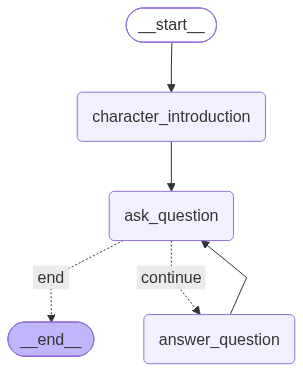

In [10]:
# Creating the Conversation Graph to act as the Conversation Loop

# Update the graph
conversation_builder = StateGraph(ConversationState)

# Add nodes
conversation_builder.add_node("character_introduction", character_introduction)
conversation_builder.add_node("ask_question", ask_question)
conversation_builder.add_node("answer_question", answer_question)

# Add edges
conversation_builder.add_edge(START, "character_introduction")
conversation_builder.add_edge("character_introduction", "ask_question")
conversation_builder.add_conditional_edges("ask_question",where_to_go,{"continue": "answer_question", "end": END})
conversation_builder.add_edge("answer_question", "ask_question")

conversation_graph = conversation_builder.compile()
# View
display(Image(conversation_graph.get_graph(xray=1).draw_mermaid_png()))

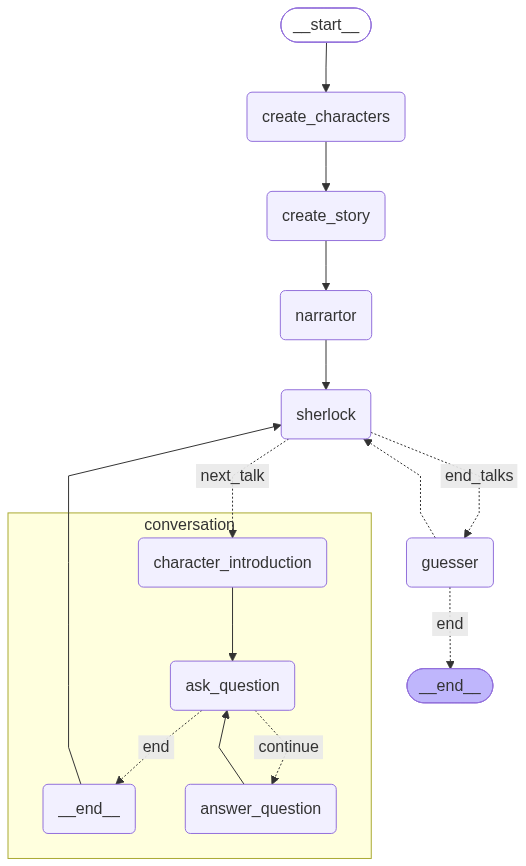

In [11]:
# Creating the Core Game Graph

# Update the graph
builder = StateGraph(GenerateGameState)

# Add nodes
builder.add_node("create_characters", create_characters)
builder.add_node("create_story", create_story)
builder.add_node("narrartor", narrartor)
builder.add_node("sherlock", sherlock)
builder.add_node("guesser", guesser)
builder.add_node("conversation", conversation)



# Add edges
builder.add_edge(START, "create_characters")
builder.add_edge("create_characters", "create_story")
builder.add_edge("create_story", "narrartor")
builder.add_edge("narrartor", "sherlock")

builder.add_conditional_edges("sherlock",
                              lambda state: "next_talk" if state.get('selected_character_id') is not None else "end_talks",
                              {
                                "next_talk": "conversation",
                                "end_talks": "guesser"
                              }
)

builder.add_edge("conversation", "sherlock")
builder.add_conditional_edges("guesser",
                              lambda state: state.get('result'),
                              {"sherlock":"sherlock","end":END})

# Compile
graph = builder.compile()
# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
# Input
max_characters = 5
num_guesses_left: int = 3
environment = "Mistral office in Paris"

output = graph.invoke({"environment":environment,"max_characters":max_characters, "num_guesses_left": num_guesses_left})